Try different sigma dependencies \& determine the best one based off of $\Delta \chi^2$

In [1]:
from escripts import eMCMC
from escripts import eplots
Plotting = eplots.Plotting()
import importlib
import time
import emcee

In [104]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [105]:
eMCMC.get_default_dict()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, 10}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


In [106]:
param_const = eMCMC.build_param_data({'dsigdlogM': {'fit':False}, 'dsigdz': {'fit':False}})

In [107]:
UVLF_const = eMCMC.UVLF(file_names, data_labels, param_const)

In [108]:
ICs_const = UVLF_const.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [164]:
# Run MCMC
Nsteps=3000
_ = UVLF_const.sampler.run_mcmc(ICs_const, Nsteps) 

In [165]:
# Get flat sample from the MCMC
samples_const, best_fit_const, labels = UVLF_const.get_fit()

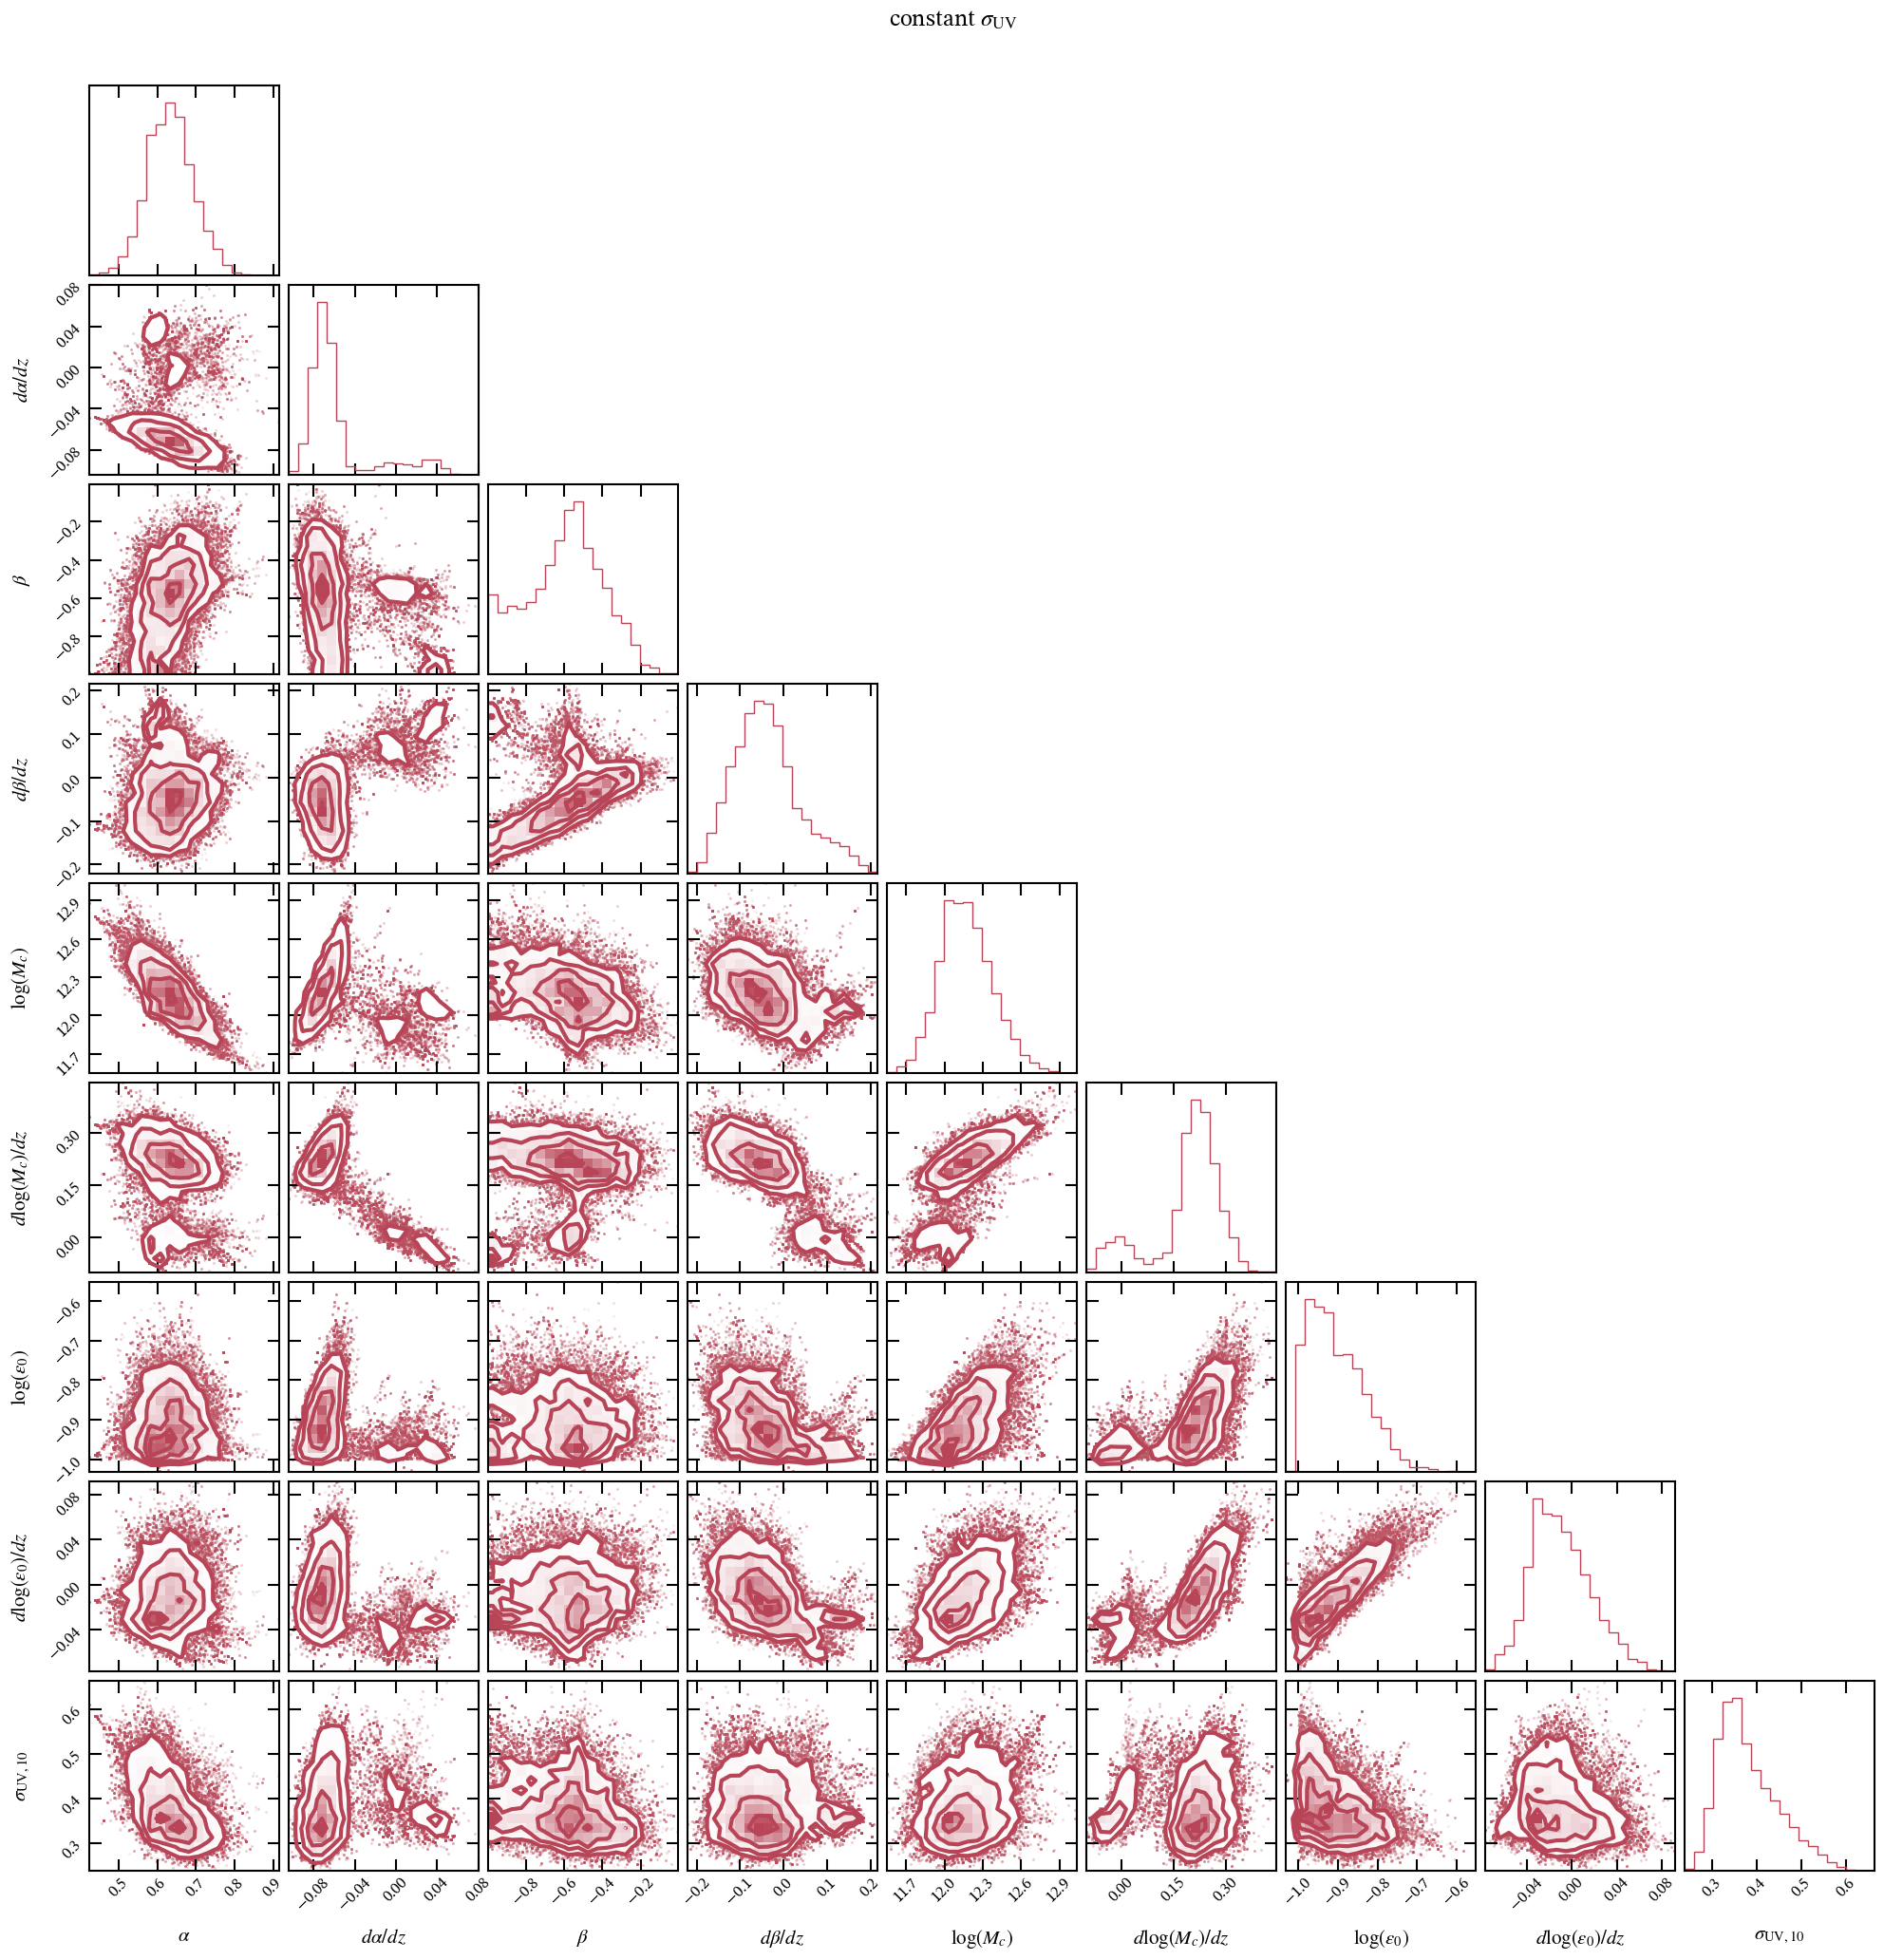

In [166]:
corner_const = Plotting.plot_corner(samples_const, UVLF_const, title = r'constant $\sigma_{\rm{UV}}$')

In [167]:
#corner_const.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/posterior_const_sig.png', bbox_inches='tight')

In [168]:
print(best_fit_const)

[0.68, -0.08, -0.43, -0.03, 12.03, 0.19, -0.91, -0.01, 0.31, 0, 0]


In [169]:
param_M = eMCMC.build_param_data({'dsigdz': {'fit': False}})

In [170]:
UVLF_M = eMCMC.UVLF(file_names, data_labels, param_M)

In [171]:
ICs_M = UVLF_M.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [172]:
# Run MCMC
_ = UVLF_M.sampler.run_mcmc(ICs_M, Nsteps) 

In [173]:
samples_M, best_fit_M, _ = UVLF_M.get_fit()

In [174]:
print(best_fit_M)

[0.63, -0.05, -0.24, 0.01, 12.45, 0.25, -0.94, -0.01, 1.16, 0, -0.39]


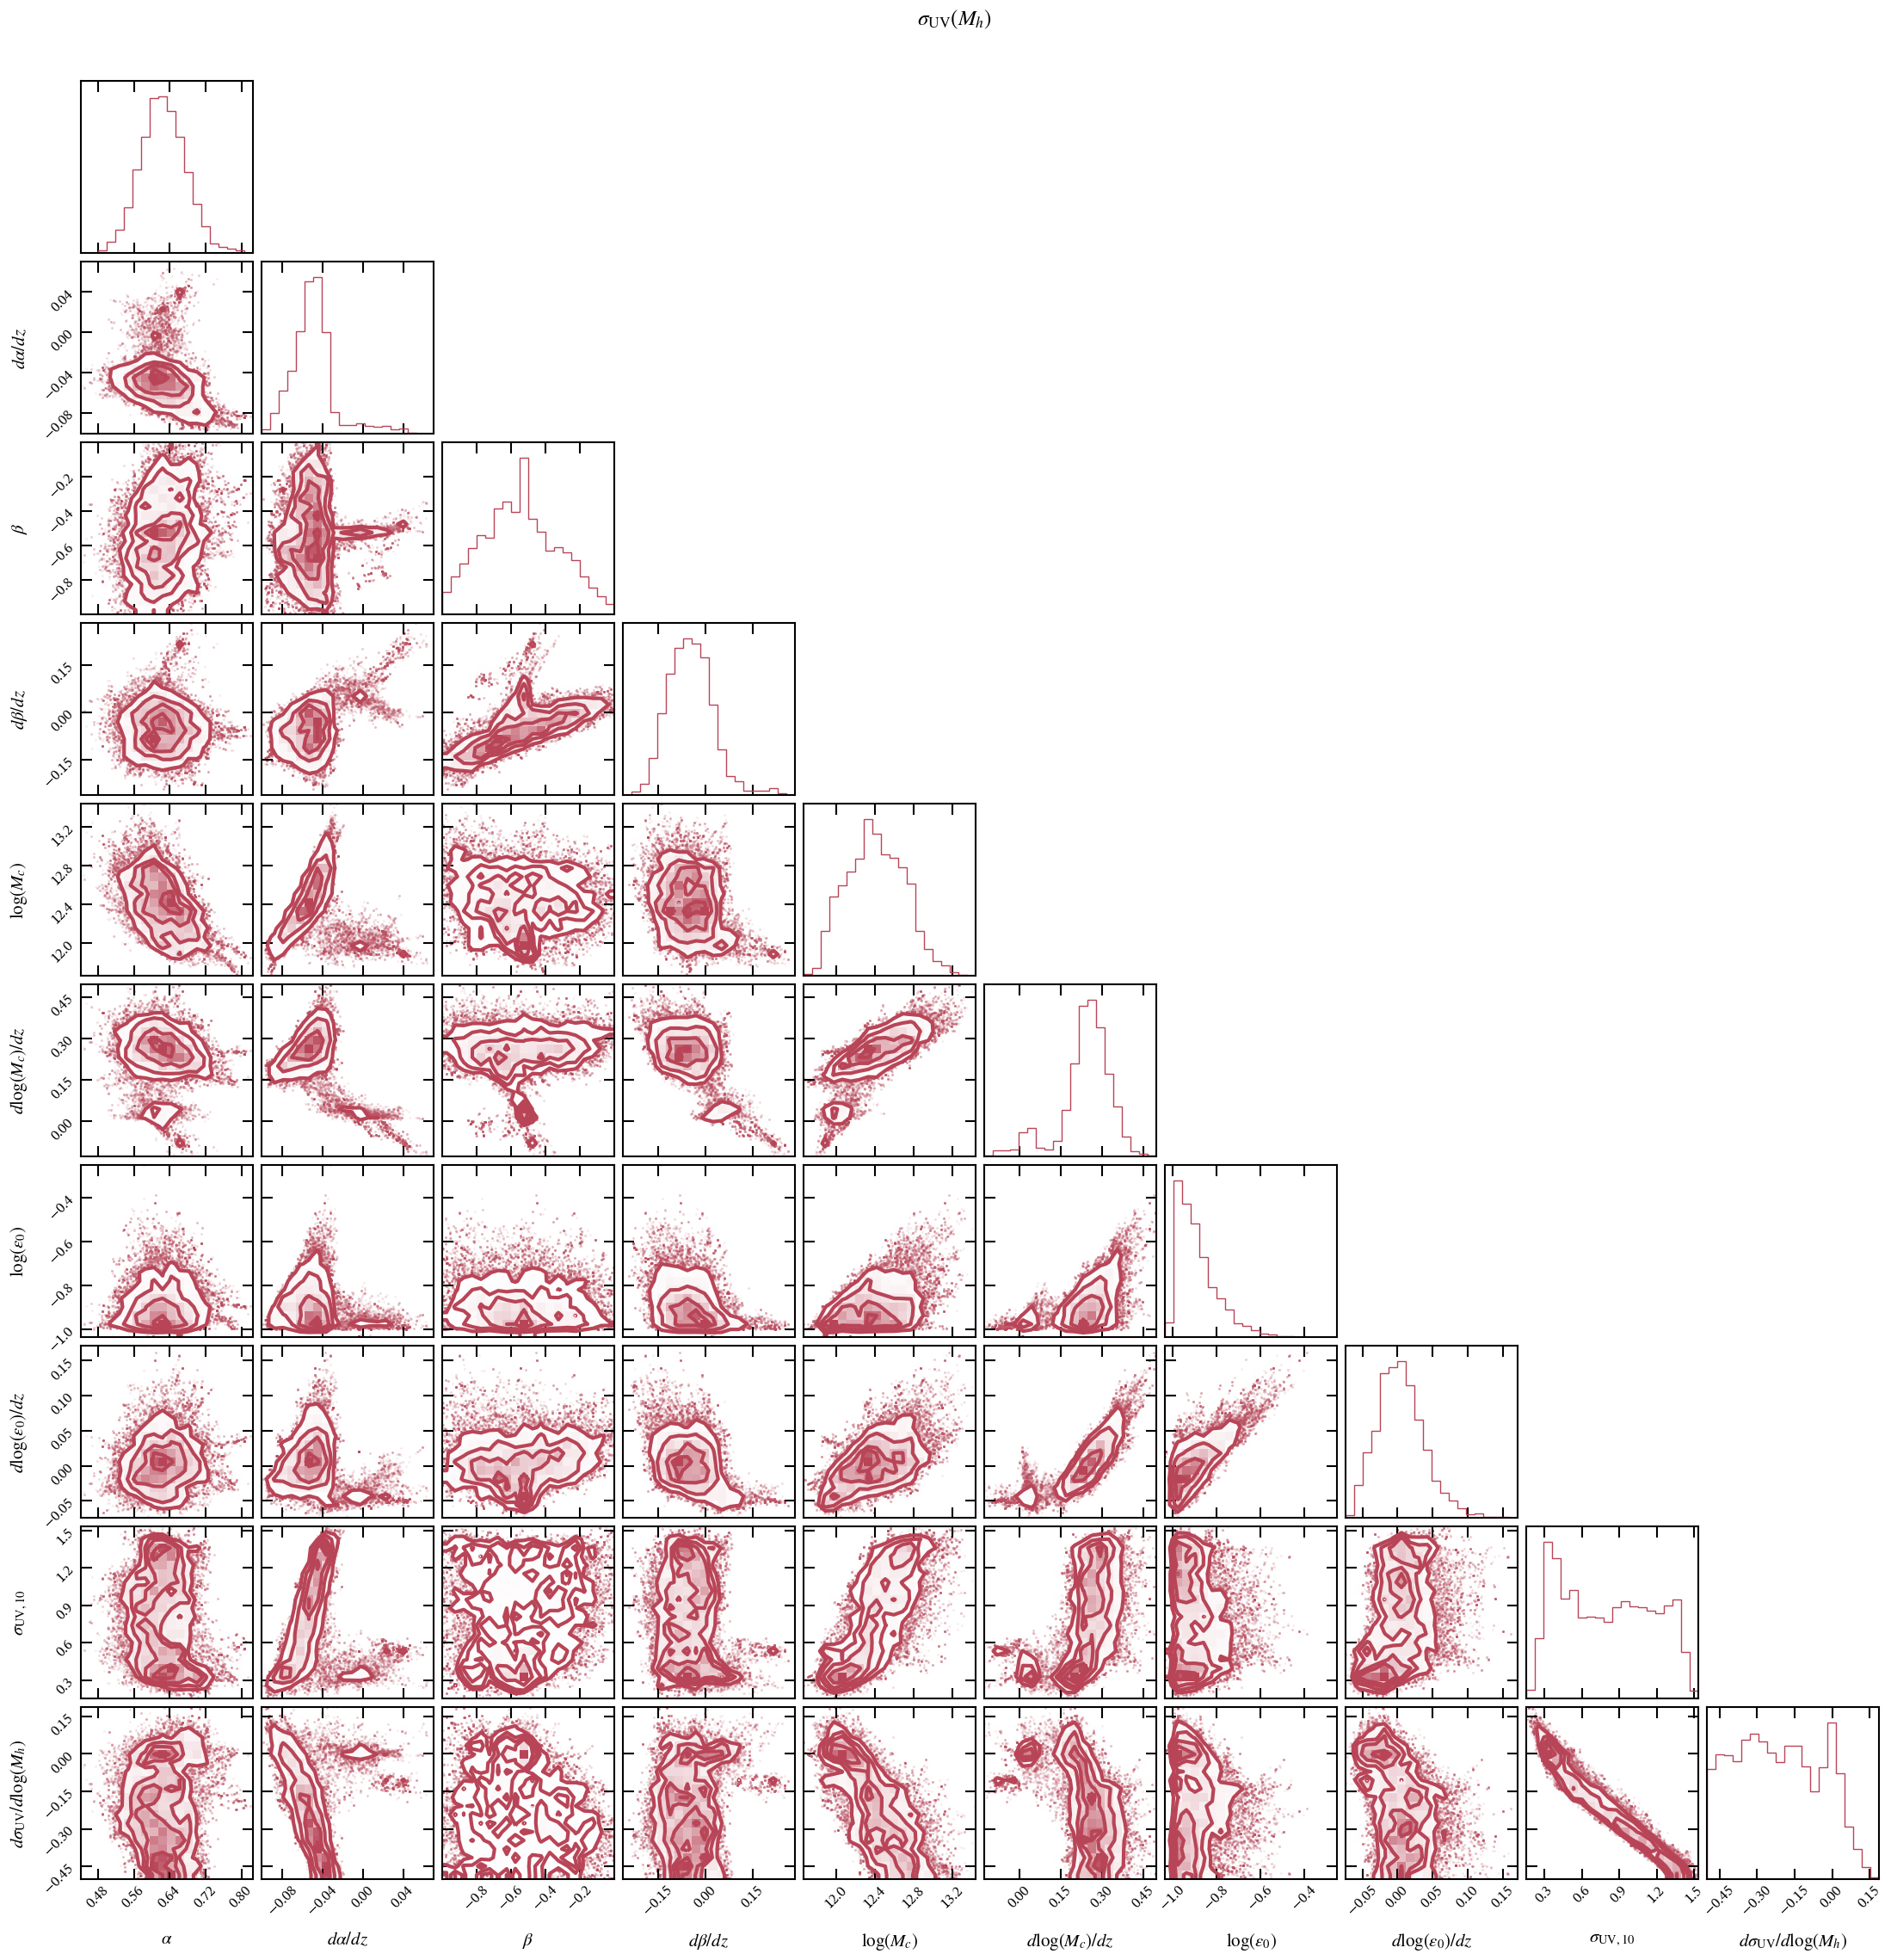

In [175]:
corner_M = Plotting.plot_corner(samples_M, UVLF_M, title = r'$\sigma_{\rm{UV}}(M_h)$')

In [176]:
#corner_M.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/weird_posterior_sig_m.png', bbox_inches='tight')

In [177]:
params_z = eMCMC.build_param_data({'dsigdlogM': {'fit': False}})

In [178]:
UVLF_z = eMCMC.UVLF(file_names, data_labels, params_z)

In [179]:
ICs_z = UVLF_z.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [180]:
# Run MCMC
_ = UVLF_z.sampler.run_mcmc(ICs_z, Nsteps) 

In [181]:
samples_z, best_fit_z, _ = UVLF_z.get_fit()

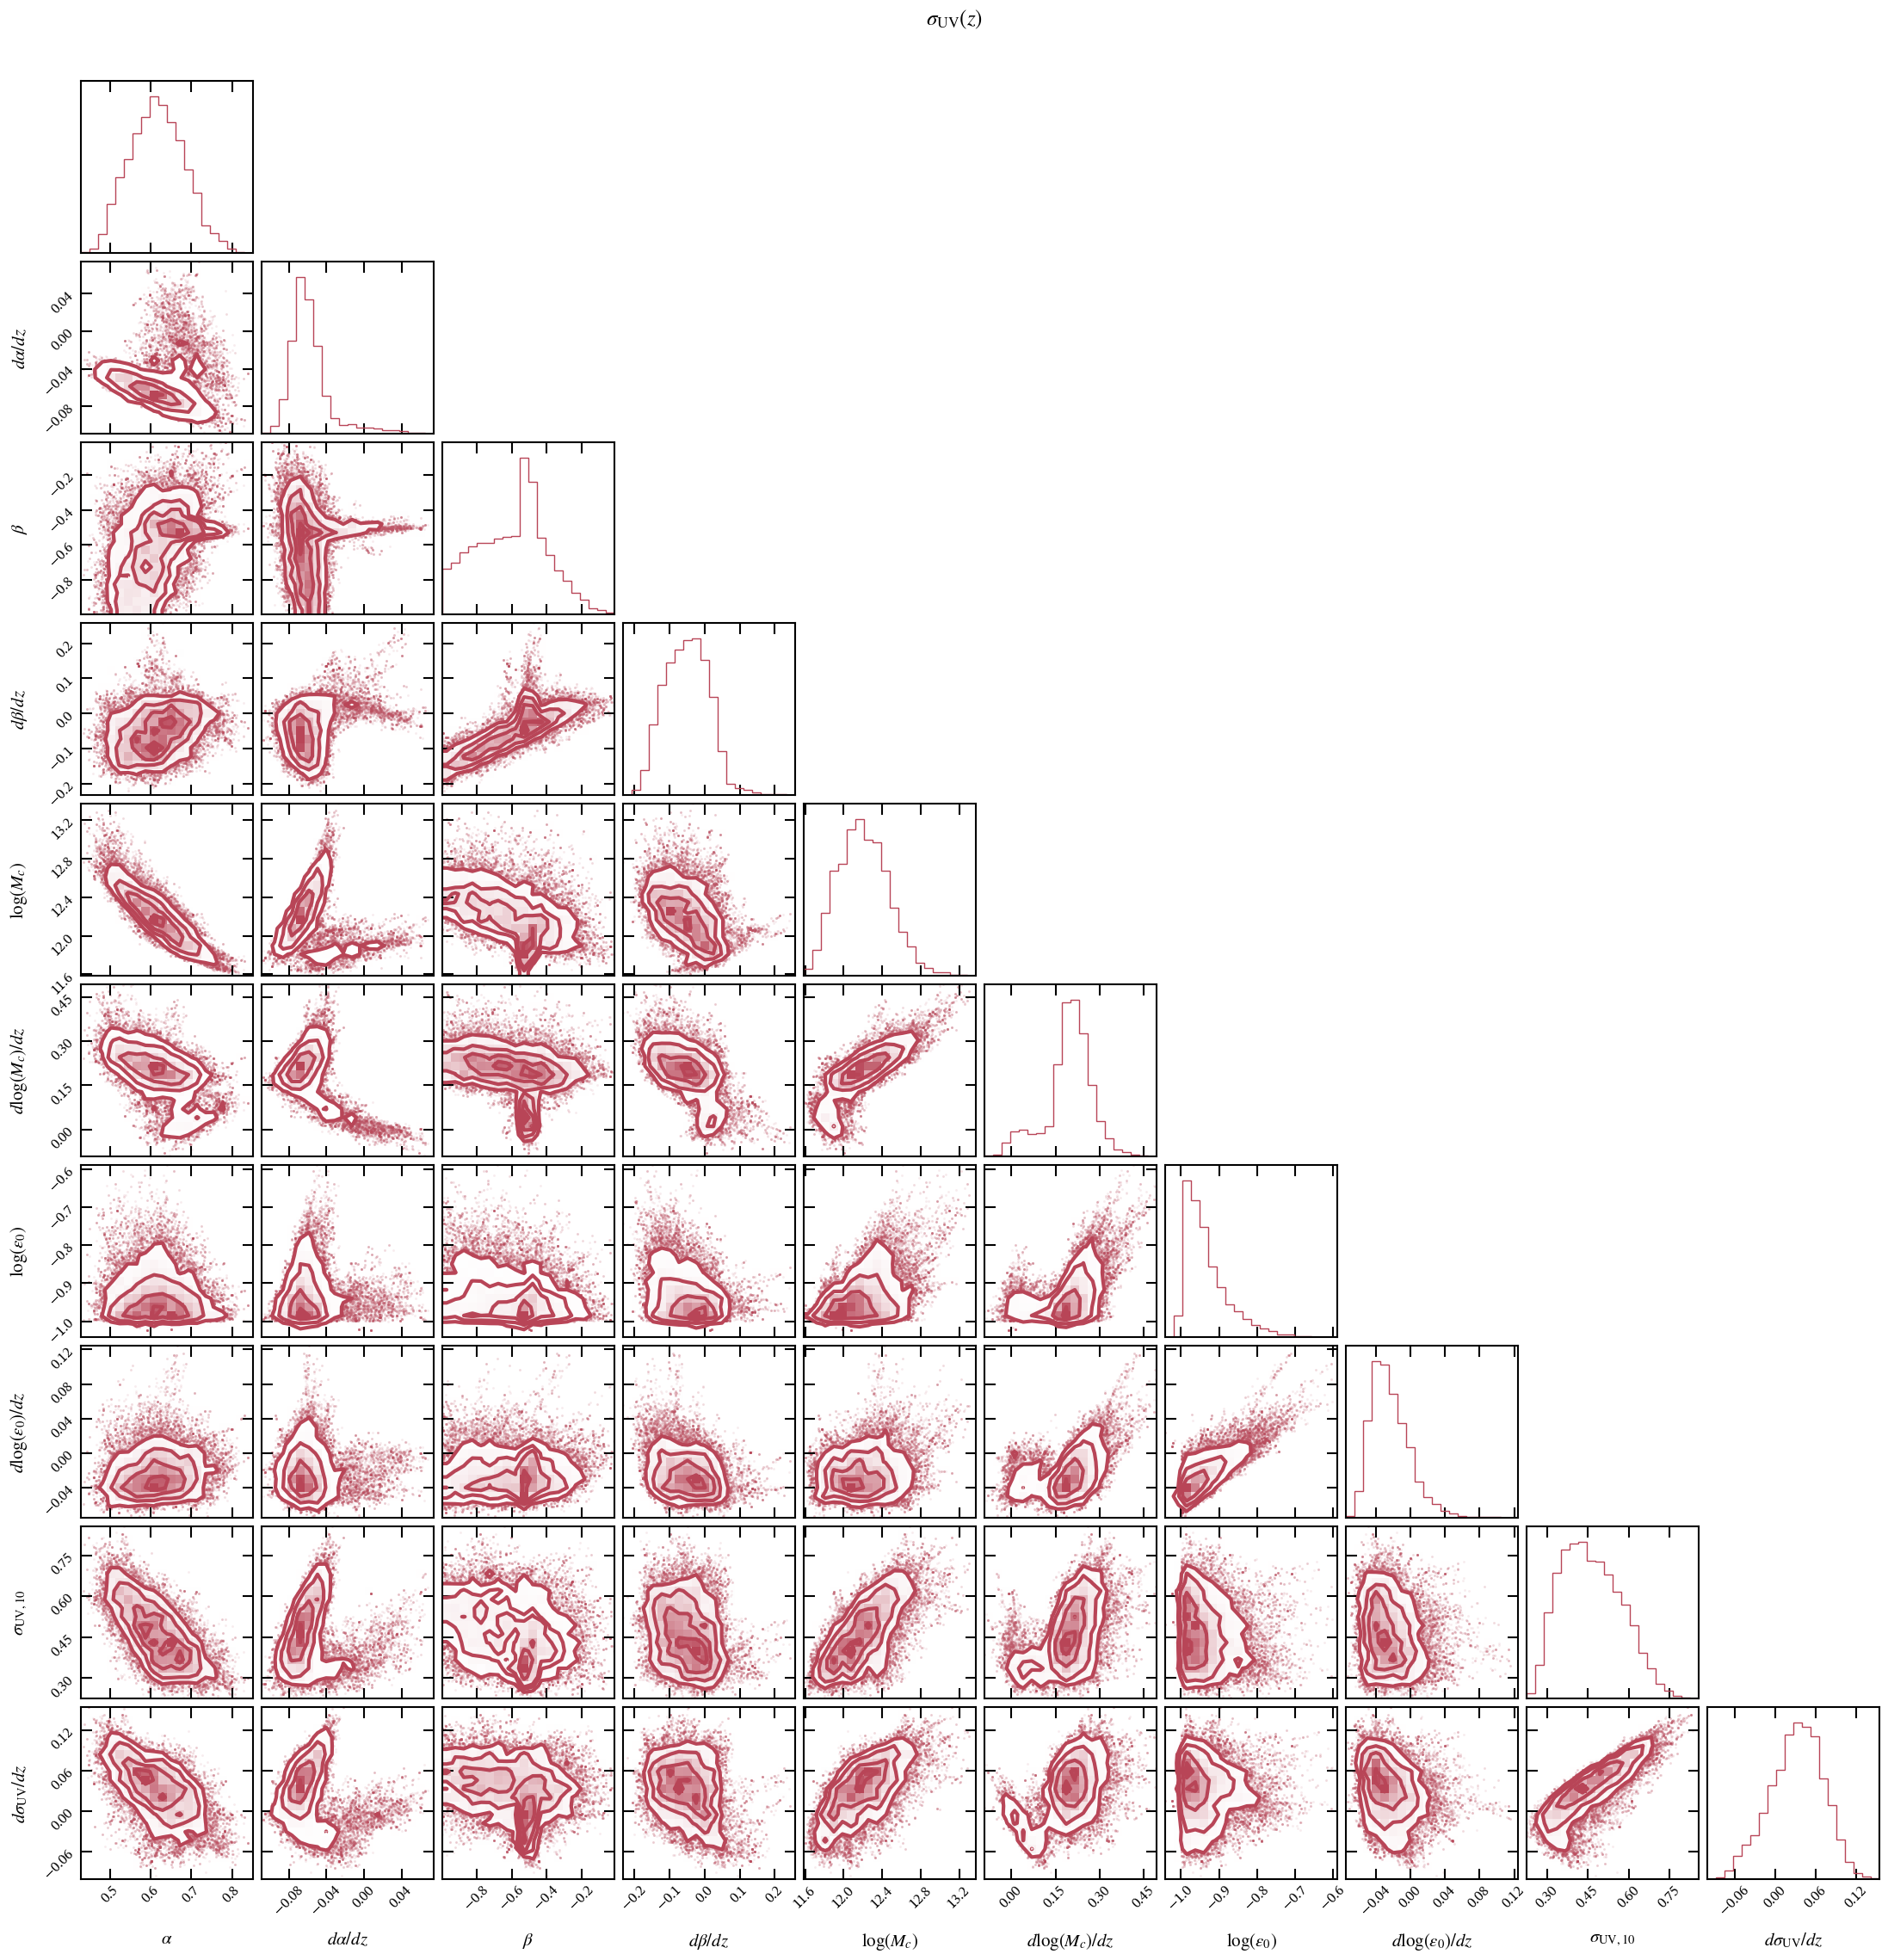

In [182]:
corner_z = Plotting.plot_corner(samples_z, UVLF_z, title = r'$\sigma_{\rm{UV}}(z)$')

In [183]:
#corner_z.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/posterior_sig_z.png', bbox_inches = 'tight')

In [184]:
print(best_fit_z)

[0.65, -0.07, -0.41, -0.01, 12.06, 0.17, -0.96, -0.04, 0.47, 0.05, 0]


In [185]:
params_all = eMCMC.build_param_data({})

In [186]:
UVLF_all = eMCMC.UVLF(file_names, data_labels, params_all)

In [187]:
ICs_all = UVLF_all.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [188]:
_ = UVLF_all.sampler.run_mcmc(ICs_all, Nsteps)

In [189]:
samples_all, best_fit_all, _ = UVLF_all.get_fit()

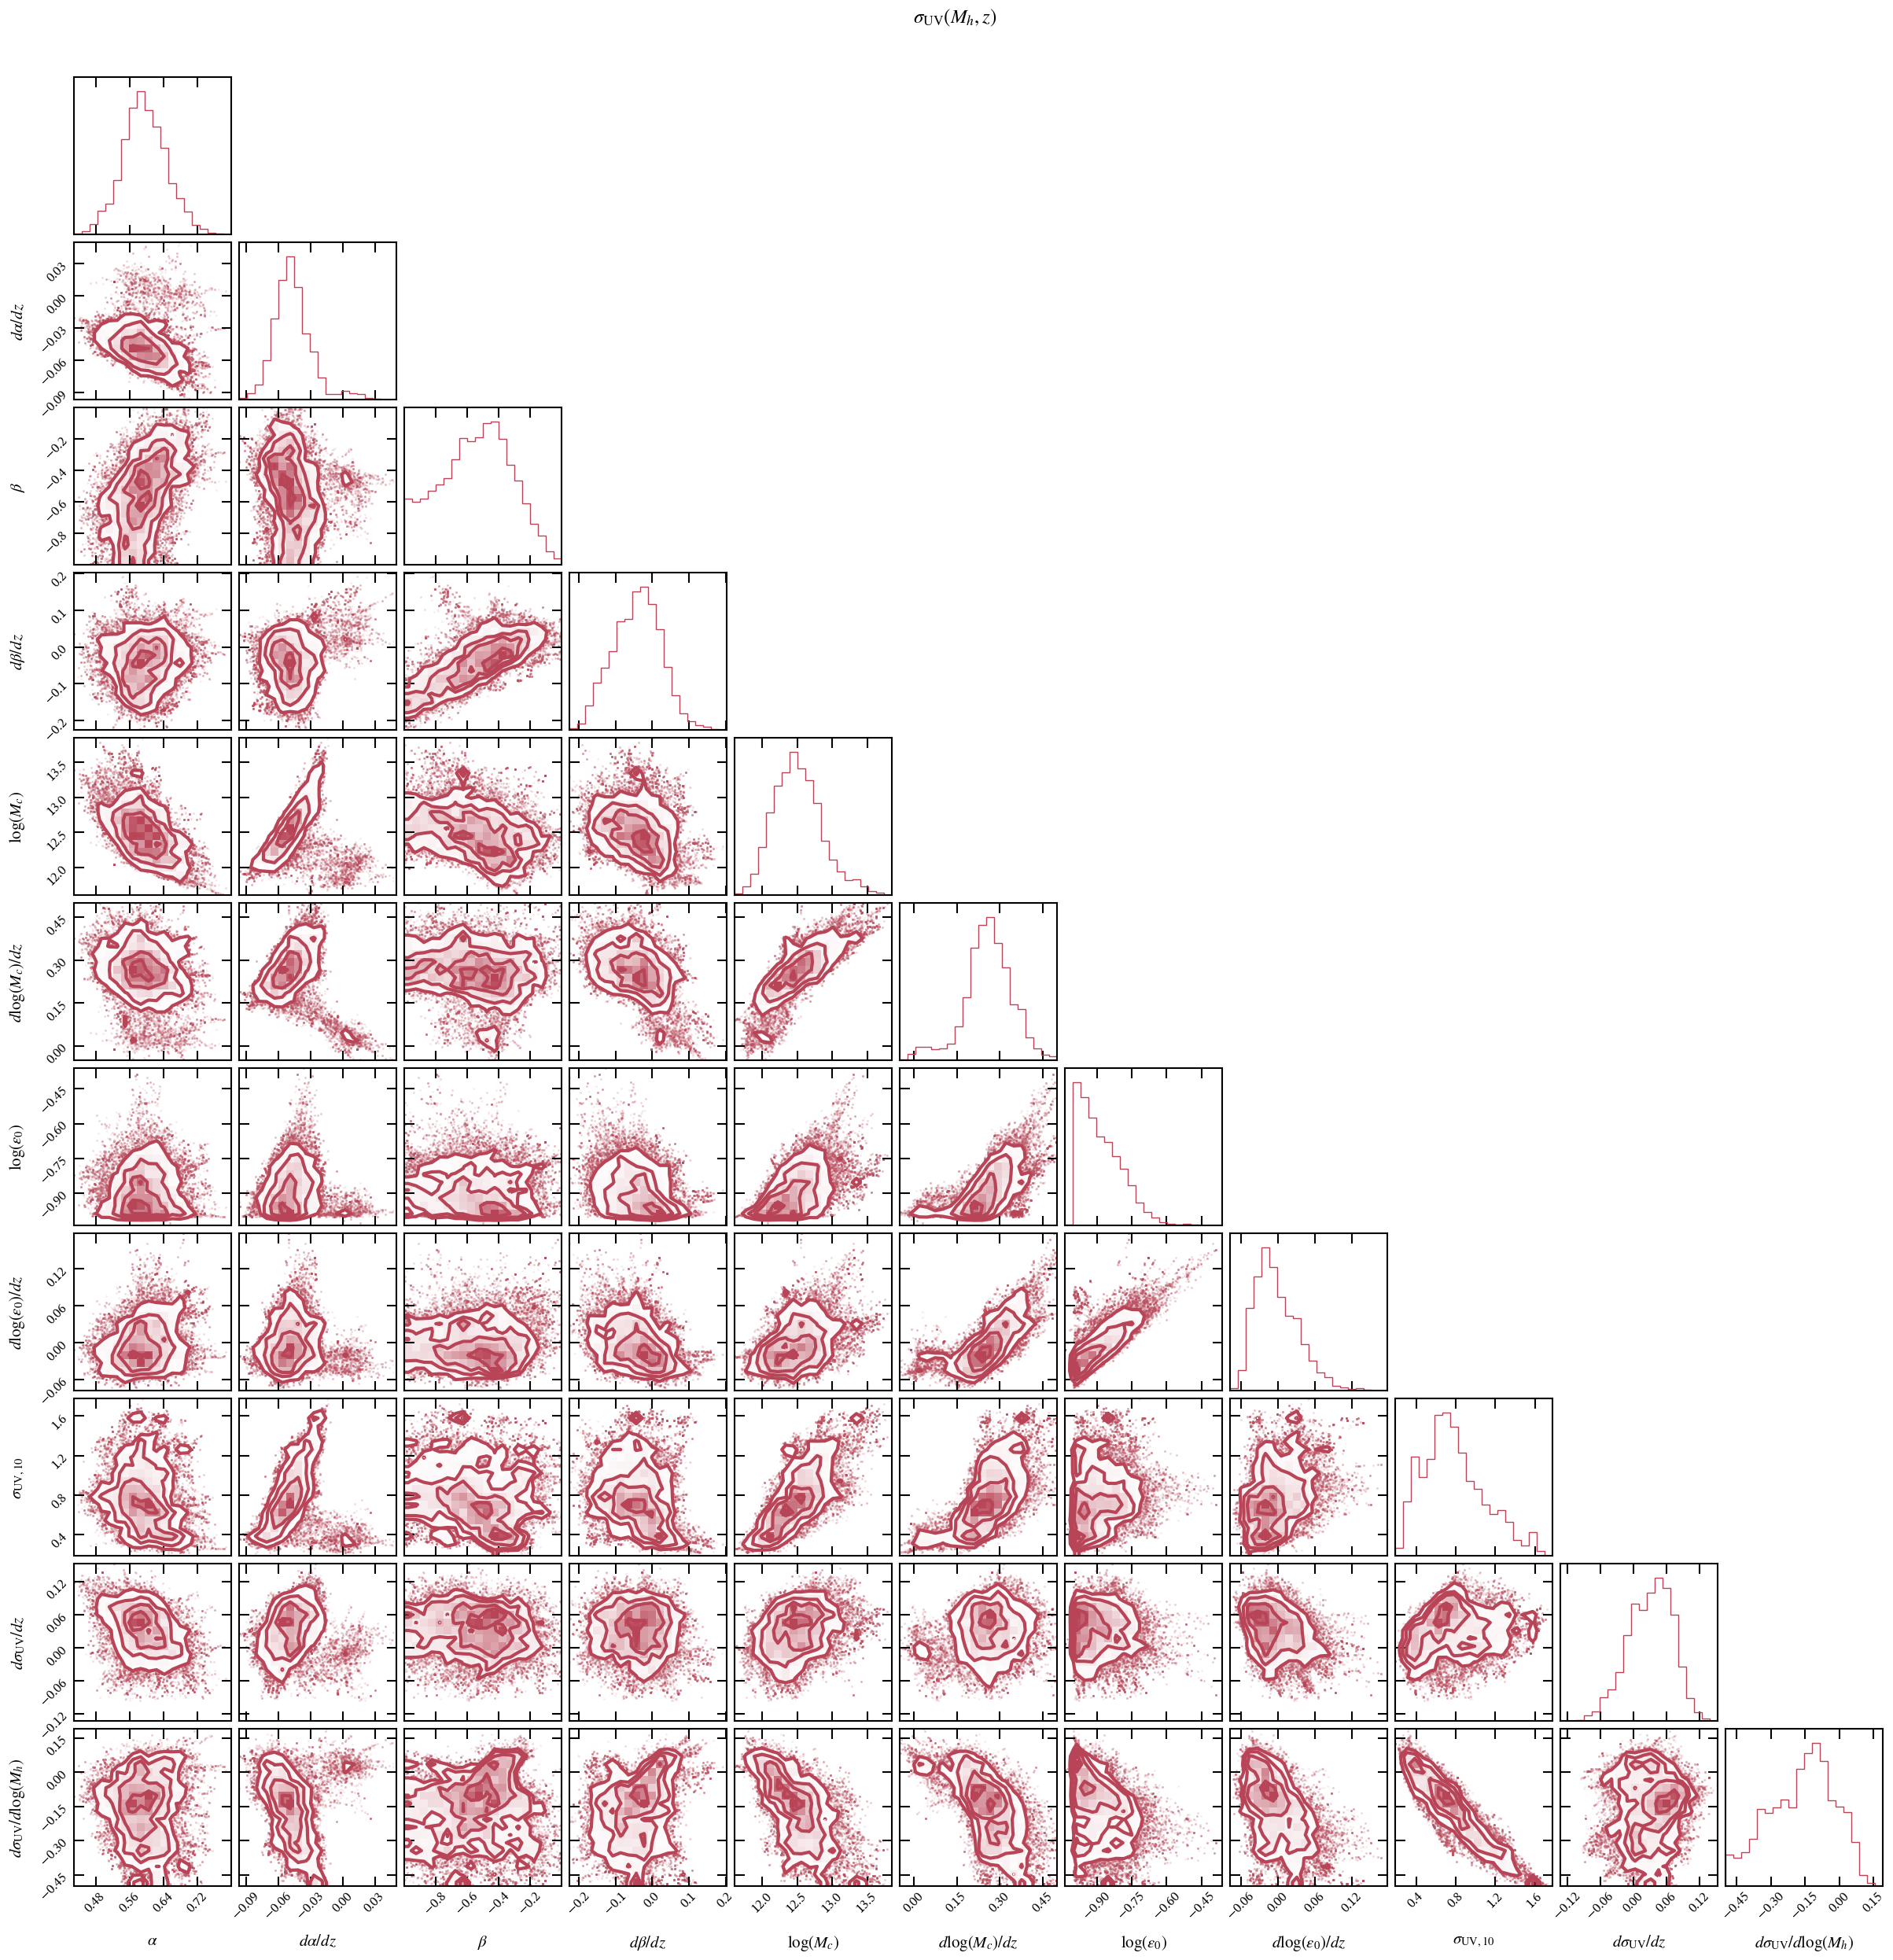

In [190]:
corner_all = Plotting.plot_corner(samples_all, UVLF_all, title = r'$\sigma_{\rm{UV}}(M_h, z)$')

In [191]:
print(best_fit_all)

[0.61, -0.06, -0.37, -0.0, 12.29, 0.2, -0.94, -0.04, 0.73, 0.07, -0.14]


In [192]:
#corner_all.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/weird_posterior_sig_mz.png', bbox_inches = 'tight')

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:224: RuntimeWarning: invalid value encountered in log10
  ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,sample)),


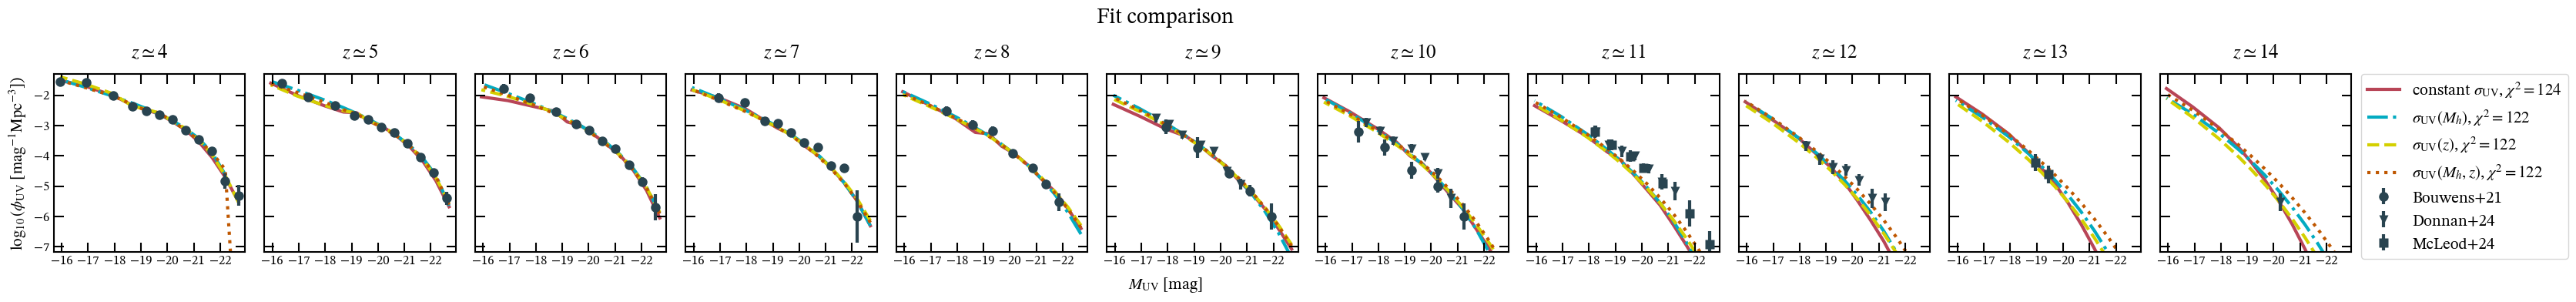

In [193]:
comparison = Plotting.compare_fits(file_names, data_labels, [best_fit_const, best_fit_M, best_fit_z, best_fit_all], 
        fit_labels = [r'constant $\sigma_{\rm{UV}}$', r'$\sigma_{\rm{UV}}(M_h)$', r'$\sigma_{\rm{UV}}(z)$', r'$\sigma_{\rm{UV}}(M_h, z)$'],
                                  title = 'Fit comparison')

In [194]:
#comparison.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/diff_sigma_func_just_HST.png', bbox_inches='tight')

In [195]:
#comparison.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/diff_sigma_func_compare.png', bbox_inches='tight')

In [196]:
table = eMCMC.make_table([best_fit_const, best_fit_M, best_fit_z, best_fit_all], labels, 
        fit_labels = [r'constant $\sigma_{\rm{UV}}$', r'$\sigma_{\rm{UV}}(M_h)$', r'$\sigma_{\rm{UV}}(z)$', r'$\sigma_{\rm{UV}}(M_h, z)$'])

In [197]:
table

,constant $\sigma_{\rm{UV}}$,$\sigma_{\rm{UV}}(M_h)$,$\sigma_{\rm{UV}}(z)$,"$\sigma_{\rm{UV}}(M_h, z)$"
$\alpha$,0.68,0.63,0.65,0.61
$d\alpha/dz$,-0.08,-0.05,-0.07,-0.06
$\beta$,-0.43,-0.24,-0.41,-0.37
$d\beta/dz$,-0.03,0.01,-0.01,-
$\log(M_c)$,12.03,12.45,12.06,12.29
$d\log(M_c)/dz$,0.19,0.25,0.17,0.2
$\log(\epsilon_0)$,-0.91,-0.94,-0.96,-0.94
$d\log(\epsilon_0)/dz$,-0.01,-0.01,-0.04,-0.04
"$\sigma_{\rm{UV}, 10}$",0.31,1.16,0.47,0.73
$d\sigma_{\rm{UV}}/dz$,-,-,0.05,0.07
